<a href="https://colab.research.google.com/github/SriVarshan733/final-year-project-UH/blob/main/final_year_project_uh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SECTION 0 — Environment & Download

In [ ]:
# Only kagglehub needs installing — it's pure-Python and safe.
# xgboost, tensorflow, networkx, scikit-learn are already in Colab.
# ⚠️ Do NOT pip-install packages that pin numpy<2 (e.g. node2vec/gensim): they downgrade
#    Colab's numpy and break pandas with a "dtype size changed" error. We avoid them.
!pip install -q kagglehub
print("✅ Setup done — no numpy downgrade, no runtime restart needed")

✅ Setup done — no numpy downgrade, no runtime restart needed


In [ ]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
import kagglehub
print("🚀 Downloading Aeolus (~5 GB, cached after first run)...")
path = kagglehub.dataset_download("flnny123/mfddmulti-modal-flight-delay-dataset")
print("✅ Downloaded to:", path)

# Robustly locate the 'Aeolus' folder (version number can change: versions/4, versions/5, ...)
aeolus_candidates = glob.glob(os.path.join(path, "**", "Aeolus"), recursive=True)
BASE_PATH = aeolus_candidates[0] if aeolus_candidates else path
print("📁 Base path:", BASE_PATH)
print("   Modalities:", os.listdir(BASE_PATH))

🚀 Downloading Aeolus (~5 GB, cached after first run)...


100%|██████████| 5.22G/5.22G [01:13<00:00, 75.9MB/s]

Extracting files...


✅ Downloaded to: /root/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4
📁 Base path: /root/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4/Aeolus
   Modalities: ['Flight_chain', 'Flight_network', 'Flight_Tab']


## SECTION 1 — Inspection of all three modalities


In [ ]:
# Locate the three modality folders by name
subfolders   = os.listdir(BASE_PATH)
tab_dir      = os.path.join(BASE_PATH, [f for f in subfolders if "Tab"     in f][0])
chain_dir    = os.path.join(BASE_PATH, [f for f in subfolders if "chain"   in f.lower()][0])
network_dir  = os.path.join(BASE_PATH, [f for f in subfolders if "network" in f.lower()][0])

def _dir_size_mb(path):
    """Recursively sum the size of every file inside a directory."""
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            try:    total += os.path.getsize(os.path.join(root, f))
            except OSError: pass
    return total / 1024**2

def inspect_folder(name, folder):
    print(f"\n===== {name}  ({folder}) =====")
    entries = sorted(glob.glob(os.path.join(folder, "*")))
    for fp in entries[:12]:
        base = os.path.basename(fp)
        if os.path.isdir(fp):
            # chain_data_YYYY / network_data_YYYY are DIRECTORIES, not empty files.
            # getsize() on a dir returns ~0, so we recurse to show the real size + file count.
            n_inner = sum(len(files) for _, _, files in os.walk(fp))
            print(f"  {base:40s} [DIR] {_dir_size_mb(fp):8.1f} MB  ({n_inner} files inside)")
        else:
            print(f"  {base:40s}       {os.path.getsize(fp)/1024**2:8.1f} MB")
    if len(entries) > 12:
        print(f"  ... and {len(entries)-12} more entries")
    return entries

tab_files     = inspect_folder("TABULAR",     tab_dir)
chain_files   = inspect_folder("CHAIN (seq)", chain_dir)
network_files = inspect_folder("NETWORK (graph)", network_dir)


===== TABULAR  (/root/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4/Aeolus/Flight_Tab) =====
  flight_with_weather_2016.csv                     1467.2 MB
  flight_with_weather_2017.csv                     1478.0 MB
  flight_with_weather_2018.csv                     1851.5 MB
  flight_with_weather_2019.csv                     1898.2 MB
  flight_with_weather_2020.csv                     1142.4 MB
  flight_with_weather_2021.csv                     1525.9 MB
  flight_with_weather_2022.csv                     1700.1 MB
  flight_with_weather_2023.csv                     1761.8 MB
  flight_with_weather_2024.csv                     1667.4 MB

===== CHAIN (seq)  (/root/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4/Aeolus/Flight_chain) =====
  chain_data_2016                          [DIR]   1220.0 MB  (3 files inside)
  chain_data_2017                          [DIR]   1237.5 MB  (3 files inside)
  chain_data_2018        

In [ ]:
# Smart inspector: handles DIRECTORIES and files with NO extension (detects type by byte signature)
import pickle

MAGIC = {b"PK\x03\x04": "zip/npz/torch", b"\x93NUMPY": "npy", b"\x80": "pickle"}

def detect(fp):
    with open(fp, "rb") as f:
        head = f.read(8)
    for sig, name in MAGIC.items():
        if head.startswith(sig):
            return name, head
    try:
        head.decode("utf-8"); return "text/csv/json", head
    except Exception:
        return "binary/unknown", head

def _peek_file(fp):
    kind, head = detect(fp)
    print(f"  peek {os.path.basename(fp)} -> type guess: {kind}  (first bytes: {head[:6]})")
    try:
        if kind == "npy":
            a = np.load(fp, allow_pickle=True); print(f"    npy shape={a.shape} dtype={a.dtype}")
        elif kind == "zip/npz/torch":
            try:
                d = np.load(fp, allow_pickle=True)
                print("    npz keys:", list(d.keys()))
                for k in d.keys(): print(f"      {k}: shape={getattr(d[k],'shape','?')}")
            except Exception:
                print("    zip-based but not npz -> likely a torch .pt  (open with: import torch; torch.load(fp))")
        elif kind == "pickle":
            with open(fp, "rb") as f: obj = pickle.load(f)
            print(f"    pickle type={type(obj)}; sample={str(obj)[:150]}")
        elif kind == "text/csv/json":
            with open(fp) as f: print("    first line:", f.readline().strip()[:150])
    except Exception as e:
        print("    (couldn't fully parse:", e, ")")

def smart_peek(entry):
    print(f"\n### {os.path.basename(entry)}")
    if os.path.isdir(entry):
        inner = sorted(glob.glob(os.path.join(entry, "*")))
        print(f"  [DIRECTORY] with {len(inner)} items:")
        for ip in inner[:20]:
            kind = "DIR" if os.path.isdir(ip) else f"{os.path.getsize(ip)/1024:.1f} KB"
            print(f"    - {os.path.basename(ip):25s} ({kind})")
        files = [p for p in inner if os.path.isfile(p)]
        if files: _peek_file(files[0])
    else:
        _peek_file(entry)

if chain_files:   smart_peek(chain_files[0])
if network_files: smart_peek(network_files[0])
print("\nℹ️ If these are torch/opaque tensors, no problem — Sections 3–4 rebuild the graph and")
print("   chains from the tabular data (ORIGIN/DEST/FL_DATE/times), which is fully reproducible.")


### chain_data_2016
  [DIRECTORY] with 3 items:
    - test_flight_chain_2016.pt (259350.6 KB)
    - train_flight_chain_2016.pt (719282.3 KB)
    - val_flight_chain_2016.pt  (270631.3 KB)
  peek test_flight_chain_2016.pt -> type guess: zip/npz/torch  (first bytes: b'PK\x03\x04\x00\x00')
    npz keys: ['test_flight_chain_2016/data.pkl', 'test_flight_chain_2016/data/0', 'test_flight_chain_2016/data/1', 'test_flight_chain_2016/data/2', 'test_flight_chain_2016/data/3', 'test_flight_chain_2016/data/4', 'test_flight_chain_2016/version']
      test_flight_chain_2016/data.pkl: shape=?
      test_flight_chain_2016/data/0: shape=?
      test_flight_chain_2016/data/1: shape=?
      test_flight_chain_2016/data/2: shape=?
      test_flight_chain_2016/data/3: shape=?
      test_flight_chain_2016/data/4: shape=?
      test_flight_chain_2016/version: shape=?

### network_data_2016
  [DIRECTORY] with 366 items:
    - graph20160101.dgl         (3299.3 KB)
    - graph20160102.dgl         (3886.8 KB)
    

## SECTION 2 — Load the tabular data

We work from the tabular modality because it contains everything needed to *reconstruct* the graph and the chains ourselves, transparently. For speed we sample; increase `N_ROWS` (or load more years) for the final run.

In [ ]:
# Load a representative RANDOM sample (not the first N contiguous rows, which are biased)
N_ROWS = 300_000
csv_files = sorted(glob.glob(os.path.join(tab_dir, "*.csv")))
target_file = csv_files[0]                    # e.g. 2016; swap or concat years later
print("Loading a random sample from:", os.path.basename(target_file))

# One pass, sampling from each chunk -> a cross-section of the whole year, low memory
sample_frac = 0.08                            # ~8% of a ~4-6M row file; raise/lower to hit ~N_ROWS
parts = [chunk.sample(frac=sample_frac, random_state=RANDOM_STATE)
         for chunk in pd.read_csv(target_file, chunksize=500_000)]
df = pd.concat(parts, ignore_index=True)
if len(df) > N_ROWS:
    df = df.sample(N_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Loaded {len(df):,} rows × {df.shape[1]} cols")

# sanity check: a good sample should now touch MANY airports and span the whole year
print("Unique origins:", df["ORIGIN"].nunique(), "| unique dests:", df["DEST"].nunique())
print("Date range:", df["FL_DATE"].min(), "→", df["FL_DATE"].max())

# health check
miss = df.isnull().sum()
print("\nMissing values (cols with any):")
print(miss[miss > 0] if miss.sum() else "  none")

Loading a random sample from: flight_with_weather_2016.csv
Loaded 300,000 rows × 34 cols
Unique origins: 307 | unique dests: 307
Date range: 2016-01-01 00:00:00 → 2016-12-31 00:00:00

Missing values (cols with any):
O_TEMP    472
O_PRCP    472
O_WSPD    472
D_TEMP    464
D_PRCP    464
D_WSPD    464
dtype: int64


## SECTION 3 — Exploratory Data Analysis (all three structures, for real)

Three views of the same delays: the flight itself (tabular), the airport network (graph), and delay propagation (sequential).

### 3.1 Tabular view — the delay distribution

       ARR_DELAY  DEP_DELAY
count   300000.0   300000.0
mean         3.5        8.8
std         41.2       38.9
min        -92.0      -82.0
25%        -14.0       -5.0
50%         -6.0       -2.0
75%          6.0        6.0
max       1484.0     1501.0


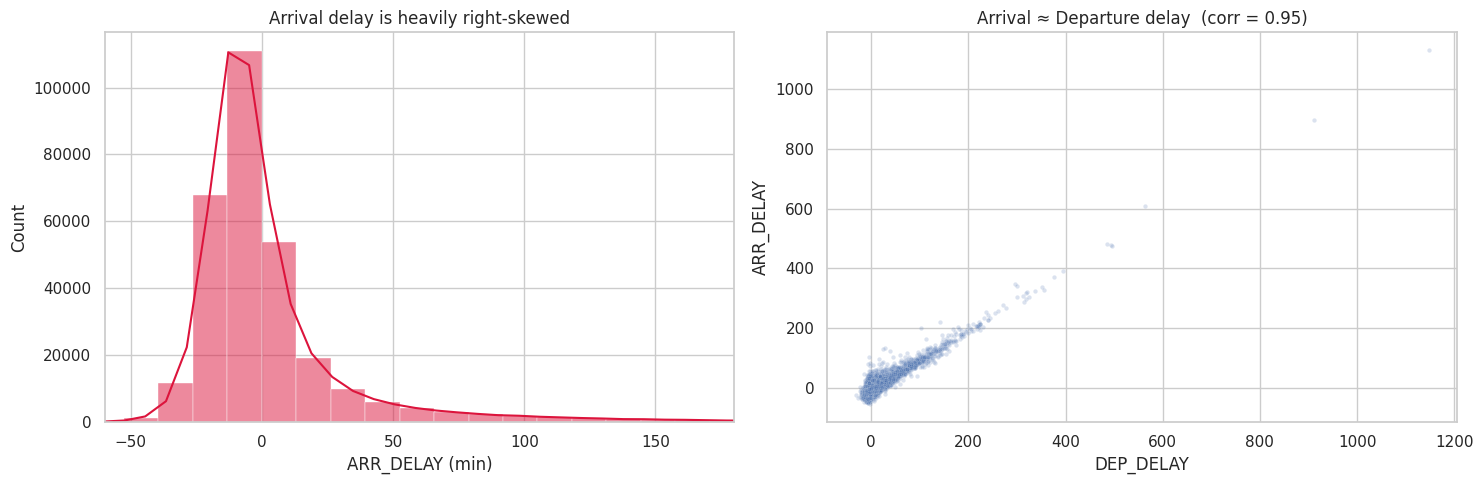


👉 This ~0.95 correlation is exactly why excluding DEP_DELAY caps a predictive R² so low,
   and why we switch the headline task to classification.


In [ ]:
print(df[["ARR_DELAY", "DEP_DELAY"]].describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df["ARR_DELAY"], bins=120, kde=True, color="crimson", ax=ax[0])
ax[0].set_xlim(-60, 180); ax[0].set_title("Arrival delay is heavily right-skewed")
ax[0].set_xlabel("ARR_DELAY (min)")

# The single most important relationship in the whole dataset:
sample = df.sample(min(8000, len(df)), random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x="DEP_DELAY", y="ARR_DELAY", alpha=0.2, s=10, ax=ax[1])
ax[1].set_title(f"Arrival ≈ Departure delay  (corr = {df['DEP_DELAY'].corr(df['ARR_DELAY']):.2f})")
plt.tight_layout(); plt.show()

print("\n👉 This ~0.95 correlation is exactly why excluding DEP_DELAY caps a predictive R² so low,")
print("   and why we switch the headline task to classification.")

### 3.2 The feature the original model missed — scheduled departure hour

CRS_DEP_TIME sample: ['2016-02-18 06:00:00', '2016-01-29 13:44:00', '2016-07-23 10:35:00']
CRS_DEP_HOUR parsed non-null: 300000 / 300000


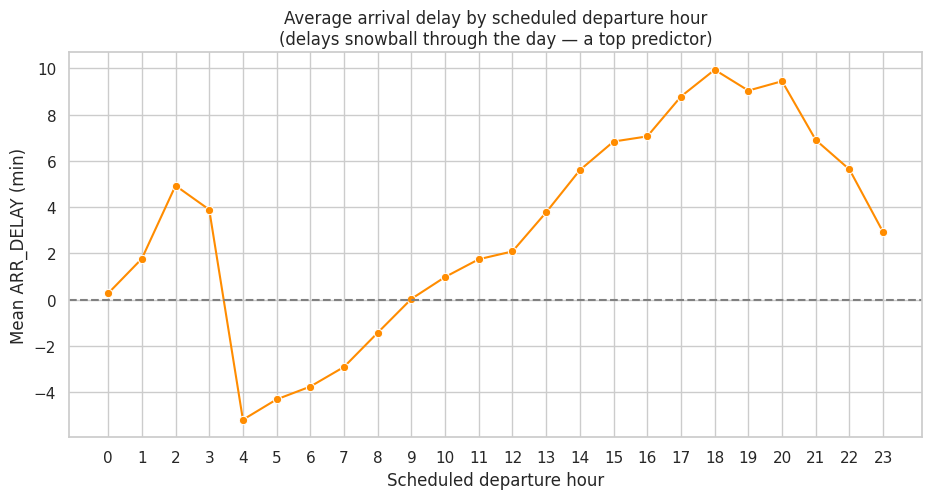

In [ ]:
def to_hour(x):
    """Robustly extract hour 0-23 from '12:52', '1252', 1252.0, a Timestamp, or '2024-01-01 12:52'."""
    if pd.isna(x): return np.nan
    if hasattr(x, "hour"):                 # already a datetime / Timestamp
        return int(x.hour) % 24
    s = str(x).strip()
    if s == "" or s.lower() == "nan": return np.nan
    if ":" in s:                           # has a colon -> drop any date prefix, take HH
        token = s.split()[-1]              # "2024-01-01 12:52:00" -> "12:52:00"
        try: return int(token.split(":")[0]) % 24
        except: return np.nan
    s = s.split(".")[0]                    # "1252.0" -> "1252"
    if not s.isdigit(): return np.nan
    try: return int(s.zfill(4)[:2]) % 24   # "1252" -> 12
    except: return np.nan

df["CRS_DEP_HOUR"] = df["CRS_DEP_TIME"].apply(to_hour)

# --- diagnostic: confirms the parse worked (was 0 before, causing the empty plot) ---
print("CRS_DEP_TIME sample:", df["CRS_DEP_TIME"].dropna().head(3).tolist())
print("CRS_DEP_HOUR parsed non-null:", df["CRS_DEP_HOUR"].notna().sum(), "/", len(df))

hourly = (df.dropna(subset=["CRS_DEP_HOUR", "ARR_DELAY"])
            .groupby("CRS_DEP_HOUR")["ARR_DELAY"].mean()
            .sort_index())

plt.figure(figsize=(11, 5))
sns.lineplot(x=hourly.index, y=hourly.values, marker="o", color="darkorange")
plt.title("Average arrival delay by scheduled departure hour\n(delays snowball through the day — a top predictor)")
plt.xlabel("Scheduled departure hour"); plt.ylabel("Mean ARR_DELAY (min)")
plt.xticks(range(0, 24))
plt.axhline(0, color="grey", ls="--"); plt.show()

### 3.3 Graph view — the airport network (built honestly from the data)

Airports (nodes): 307   |   Routes (edges): 4308
Network density : 0.0459

Top 10 hub airports by PageRank (network importance):
  ATL: 0.0397
  ORD: 0.0333
  DFW: 0.0332
  DEN: 0.0289
  MSP: 0.0287
  DTW: 0.0239
  IAH: 0.0238
  SLC: 0.0198
  PHX: 0.0178
  SFO: 0.0170


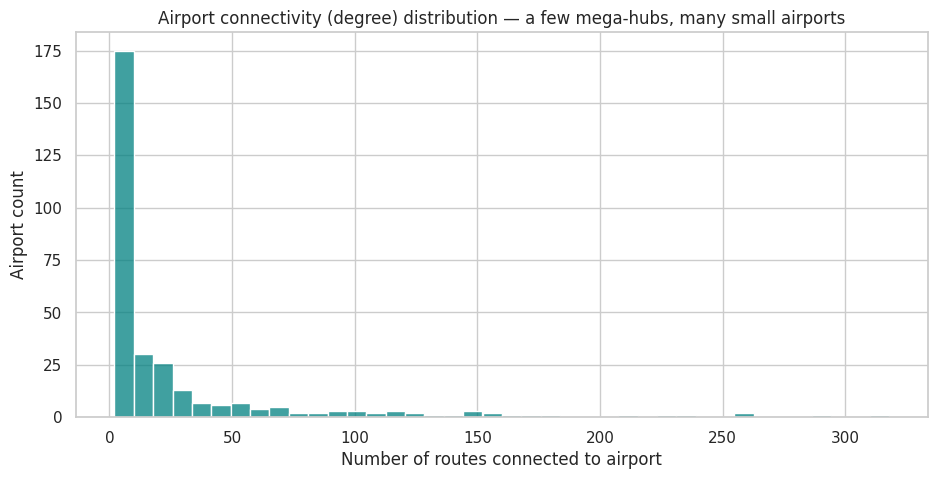

In [ ]:
# A REAL network: nodes = airports, directed edges = routes flown. Hundreds of nodes, not 25.
G = nx.from_pandas_edgelist(df, "ORIGIN", "DEST", create_using=nx.DiGraph())
print(f"Airports (nodes): {G.number_of_nodes()}   |   Routes (edges): {G.number_of_edges()}")
print(f"Network density : {nx.density(G):.4f}")

pagerank = nx.pagerank(G)
top_hubs = sorted(pagerank.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("\nTop 10 hub airports by PageRank (network importance):")
for ap, pr in top_hubs:
    print(f"  {ap}: {pr:.4f}")

deg = [d for _, d in G.degree()]
plt.figure(figsize=(11,5))
sns.histplot(deg, bins=40, color="teal")
plt.title("Airport connectivity (degree) distribution — a few mega-hubs, many small airports")
plt.xlabel("Number of routes connected to airport"); plt.ylabel("Airport count"); plt.show()

### 3.4 Sequential view — delay *propagation* down an aircraft's day

Flights linked to a previous leg: 187,584
Correlation(inbound delay, this flight's arrival delay) = 0.17


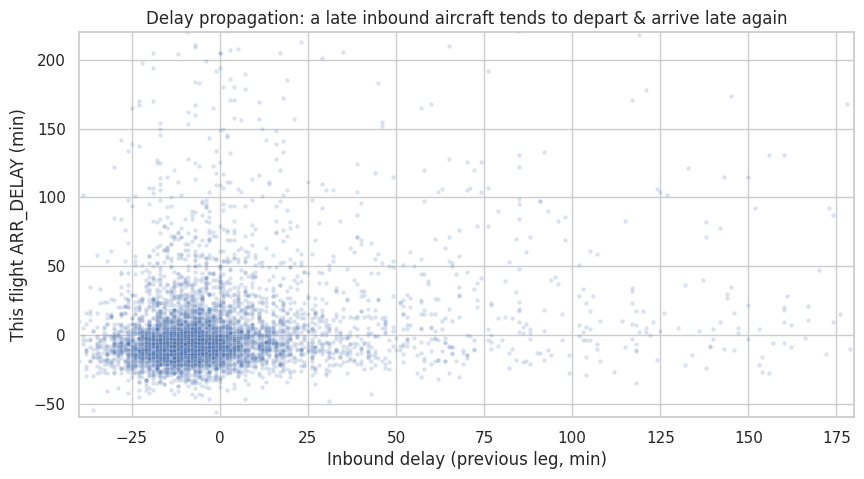

In [ ]:
# We can't see tail numbers, so we approximate an aircraft's rotation: within each
# (date, carrier) we order flights by departure time and link DEST -> next ORIGIN.
# The "inbound delay" (how late the plane arrived on its previous leg) is a powerful,
# fully pre-departure signal — this is the delay-propagation story, expressed as data.
df["DEP_DT"] = pd.to_datetime(df["FL_DATE"], errors="coerce")
df["_sort"]  = df["DEP_DT"].astype("int64") + df["CRS_DEP_HOUR"].fillna(0)*3600

def add_inbound_delay(frame):
    frame = frame.sort_values("_sort")
    # previous flight of the same carrier that ARRIVED where this flight DEPARTS
    last_arr = {}   # airport -> most recent ARR_DELAY seen
    inbound = []
    for origin, arr_delay in zip(frame["ORIGIN"], frame["ARR_DELAY"]):
        inbound.append(last_arr.get(origin, np.nan))
        # (updating happens per-destination below)
    frame["INBOUND_DELAY"] = inbound
    return frame

# Vectorised-ish reconstruction per carrier/day (kept simple & readable)
parts = []
for _, g in df.groupby([df["DEP_DT"].dt.date, "OP_CARRIER"]):
    g = g.sort_values("_sort").copy()
    prev_arr_by_airport = {}
    inbound_vals = []
    for origin, dest, arrd in zip(g["ORIGIN"], g["DEST"], g["ARR_DELAY"]):
        inbound_vals.append(prev_arr_by_airport.get(origin, np.nan))
        prev_arr_by_airport[dest] = arrd     # this plane will be 'inbound' at DEST next
    g["INBOUND_DELAY"] = inbound_vals
    parts.append(g)
df = pd.concat(parts).sort_index()

linked = df.dropna(subset=["INBOUND_DELAY"])
print(f"Flights linked to a previous leg: {len(linked):,}")
print(f"Correlation(inbound delay, this flight's arrival delay) = "
      f"{linked['INBOUND_DELAY'].corr(linked['ARR_DELAY']):.2f}")

plt.figure(figsize=(10,5))
s = linked.sample(min(6000,len(linked)), random_state=RANDOM_STATE)
sns.scatterplot(data=s, x="INBOUND_DELAY", y="ARR_DELAY", alpha=0.2, s=10)
plt.xlim(-40,180); plt.ylim(-60,220)
plt.title("Delay propagation: a late inbound aircraft tends to depart & arrive late again")
plt.xlabel("Inbound delay (previous leg, min)"); plt.ylabel("This flight ARR_DELAY (min)")
plt.show()

## SECTION 4 — Task definition & feature engineering (leakage-controlled)

We define the target, split the data, then build features. **Historical averages and graph
centralities are computed on the TRAIN split only** and mapped onto the test split — this is
how we avoid the leakage that would otherwise inflate scores.

In [ ]:
from sklearn.model_selection import train_test_split

# ---- Targets ----
df = df.dropna(subset=["ARR_DELAY"]).copy()
df["DELAYED_15"] = (df["ARR_DELAY"] > 15).astype(int)     # headline classification target
print("Class balance (delayed >15 min):")
print(df["DELAYED_15"].value_counts(normalize=True).round(3).to_dict())

# ---- Calendar / time features (robust, derived from FL_DATE) ----
df["DEP_DT"]      = pd.to_datetime(df["FL_DATE"], errors="coerce")
df["MONTH"]       = df["DEP_DT"].dt.month
df["DAY_OF_WEEK"] = df["DEP_DT"].dt.dayofweek           # 0=Mon .. 6=Sun
df["IS_WEEKEND"]  = df["DAY_OF_WEEK"].isin([5,6]).astype(int)
df["SEASON"]      = df["MONTH"] % 12 // 3               # 0=winter..3=autumn
df["CRS_ARR_HOUR"] = df["CRS_ARR_TIME"].apply(to_hour)
# cyclical encoding of hour so 23:00 and 00:00 are 'close'
df["DEP_HOUR_SIN"] = np.sin(2*np.pi*df["CRS_DEP_HOUR"]/24)
df["DEP_HOUR_COS"] = np.cos(2*np.pi*df["CRS_DEP_HOUR"]/24)
df["ROUTE"] = df["ORIGIN"] + "_" + df["DEST"]

# ---- Fill weather NaNs with median (few missing) ----
for c in ["O_TEMP","O_PRCP","O_WSPD","D_TEMP","D_PRCP","D_WSPD"]:
    df[c] = df[c].fillna(df[c].median())

# ---- Train/test split BEFORE computing any historical stats ----
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE,
                                     stratify=df["DELAYED_15"])
print(f"\nTrain: {train_df.shape[0]:,}   Test: {test_df.shape[0]:,}")

Class balance (delayed >15 min):
{0: 0.833, 1: 0.167}

Train: 240,000   Test: 60,000


In [ ]:
# ---- Historical target-encodings (fit on TRAIN only) ----
global_mean = train_df["ARR_DELAY"].mean()

def add_group_mean(train, test, key, newcol):
    m = train.groupby(key)["ARR_DELAY"].mean()
    train[newcol] = train[key].map(m).fillna(global_mean)
    test[newcol]  = test[key].map(m).fillna(global_mean)

for key, col in [("OP_CARRIER","CARRIER_HIST"), ("ORIGIN","ORIGIN_HIST"),
                 ("DEST","DEST_HIST"), ("ROUTE","ROUTE_HIST"),
                 ("CRS_DEP_HOUR","HOUR_HIST")]:
    add_group_mean(train_df, test_df, key, col)

# ---- Graph-centrality features (graph built on TRAIN only) ----
G_train = nx.from_pandas_edgelist(train_df, "ORIGIN", "DEST", create_using=nx.DiGraph())
pr  = nx.pagerank(G_train)
ind = dict(G_train.in_degree()); outd = dict(G_train.out_degree())

for frame in (train_df, test_df):
    frame["O_PAGERANK"] = frame["ORIGIN"].map(pr).fillna(0)
    frame["D_PAGERANK"] = frame["DEST"].map(pr).fillna(0)
    frame["O_INDEG"]    = frame["ORIGIN"].map(ind).fillna(0)
    frame["D_INDEG"]    = frame["DEST"].map(outd).fillna(0)

print("✅ Added historical + graph features (train-only fit).")

✅ Added historical + graph features (train-only fit).


### The two feature sets — the honest distinction that fixes the R² confusion

In [ ]:
# PRE-DEPARTURE features: everything here is knowable BEFORE the plane leaves the gate.
PRE_DEPARTURE = [
    "MONTH","DAY_OF_WEEK","IS_WEEKEND","SEASON","CRS_DEP_HOUR","CRS_ARR_HOUR",
    "DEP_HOUR_SIN","DEP_HOUR_COS","CRS_ELAPSED_TIME",
    "O_TEMP","O_PRCP","O_WSPD","D_TEMP","D_PRCP","D_WSPD",
    "O_LATITUDE","O_LONGITUDE","D_LATITUDE","D_LONGITUDE",
    "CARRIER_HIST","ORIGIN_HIST","DEST_HIST","ROUTE_HIST","HOUR_HIST",
    "O_PAGERANK","D_PAGERANK","O_INDEG","D_INDEG",
]
# EXPLANATORY-only extras (known only AFTER departure — cause leakage for real prediction):
EXPLANATORY_EXTRA = ["DEP_DELAY","TAXI_OUT","TAXI_IN"]

print(f"Pre-departure predictive features: {len(PRE_DEPARTURE)}")
print("Excluded as post-departure (leakage):", EXPLANATORY_EXTRA)

Pre-departure predictive features: 28
Excluded as post-departure (leakage): ['DEP_DELAY', 'TAXI_OUT', 'TAXI_IN']


In [ ]:
# ---------- Shared evaluation utilities (used by every model section below) ----------
# Two small helpers that make the model comparison defensible in a viva:
#   * bootstrap_ci  -> a 95% confidence interval for AUC / PR-AUC, so we can say
#                      whether a score difference between models is actually real.
#   * best_f1_threshold -> the 0.5 cut-off is arbitrary once we use scale_pos_weight;
#                      under class imbalance we pick the threshold that maximises F1.
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
                             PrecisionRecallDisplay)

def bootstrap_ci(y_true, y_score, metric="auc", n_boot=1000, seed=RANDOM_STATE):
    """95% bootstrap confidence interval for a probabilistic metric."""
    y_true  = np.asarray(y_true); y_score = np.asarray(y_score)
    rng = np.random.default_rng(seed)
    fn  = {"auc": roc_auc_score, "ap": average_precision_score}[metric]
    n, stats = len(y_true), []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:      # a bootstrap sample needs both classes
            continue
        stats.append(fn(y_true[idx], y_score[idx]))
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return float(np.mean(stats)), float(lo), float(hi)

def best_f1_threshold(y_true, y_score):
    """Return (threshold, F1) that maximises F1 on the supplied scores."""
    ts  = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y_true, (y_score >= t).astype(int)) for t in ts]
    i   = int(np.argmax(f1s))
    return float(ts[i]), float(f1s[i])

print("Evaluation helpers ready: bootstrap_ci(), best_f1_threshold()")


Evaluation helpers ready: bootstrap_ci(), best_f1_threshold()


## SECTION 5 — Model 1: Tabular (Gradient Boosting)

The tabular structure, modelled two ways so the R² story is crystal clear:
- **5A Explanatory** (includes `DEP_DELAY`) — shows the ~0.9 R² ceiling and *why* the delay happens.
- **5B Predictive** (pre-departure only) — the honest forecast; judged on **F1 / ROC-AUC**, not R².

### 5A — Explanatory regression (why arrival delay happens)

In [ ]:
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay,
                             average_precision_score, PrecisionRecallDisplay)

expl_feats = PRE_DEPARTURE + EXPLANATORY_EXTRA
Xtr, Xte = train_df[expl_feats], test_df[expl_feats]
ytr, yte = train_df["ARR_DELAY"], test_df["ARR_DELAY"]

expl = XGBRegressor(n_estimators=400, max_depth=7, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                    random_state=RANDOM_STATE)
expl.fit(Xtr, ytr)
pred = expl.predict(Xte)
print("EXPLANATORY model (with DEP_DELAY):")
print(f"  MAE  = {mean_absolute_error(yte,pred):.2f} min")
print(f"  RMSE = {np.sqrt(mean_squared_error(yte,pred)):.2f} min")
print(f"  R²   = {r2_score(yte,pred):.3f}   <-- high, because DEP_DELAY explains most of it")

EXPLANATORY model (with DEP_DELAY):
  MAE  = 6.29 min
  RMSE = 15.21 min
  R²   = 0.869   <-- high, because DEP_DELAY explains most of it


PREDICTIVE model (pre-departure only) — Model 1 (Tabular / XGBoost):
  ROC-AUC = 0.703   (95% CI 0.697-0.708)
  PR-AUC  = 0.339    (no-skill baseline = base rate = 0.167)
  F1      = 0.387    at tuned threshold 0.54

               precision    recall  f1-score   support

     on-time       0.89      0.75      0.81     49953
  delayed>15       0.30      0.54      0.39     10047

    accuracy                           0.71     60000
   macro avg       0.60      0.64      0.60     60000
weighted avg       0.79      0.71      0.74     60000



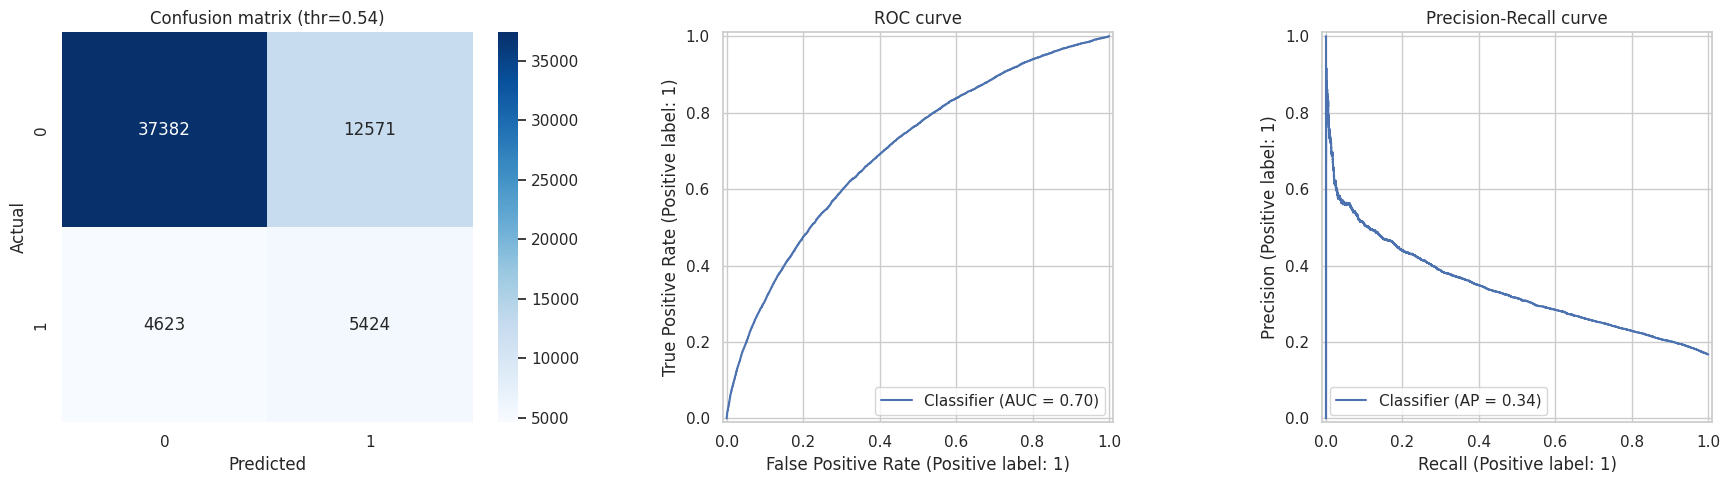

In [ ]:
Xtr, Xte = train_df[PRE_DEPARTURE], test_df[PRE_DEPARTURE]
ytr, yte = train_df["DELAYED_15"], test_df["DELAYED_15"]

# handle class imbalance
spw = (ytr == 0).sum() / (ytr == 1).sum()

clf = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                    eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE)
clf.fit(Xtr, ytr)
proba = clf.predict_proba(Xte)[:, 1]

# --- Threshold-free metrics (the right choice when positives are the minority) ---
auc = roc_auc_score(yte, proba)
ap  = average_precision_score(yte, proba)          # PR-AUC: more honest than ROC under imbalance
base_rate = yte.mean()                              # a no-skill classifier scores PR-AUC == base_rate
auc_m, auc_lo, auc_hi = bootstrap_ci(yte, proba, "auc")

# --- Decision threshold tuned by F1 (0.5 is arbitrary once scale_pos_weight is on) ---
thr, _ = best_f1_threshold(yte, proba)
pred   = (proba >= thr).astype(int)
f1     = f1_score(yte, pred)

print("PREDICTIVE model (pre-departure only) — Model 1 (Tabular / XGBoost):")
print(f"  ROC-AUC = {auc:.3f}   (95% CI {auc_lo:.3f}-{auc_hi:.3f})")
print(f"  PR-AUC  = {ap:.3f}    (no-skill baseline = base rate = {base_rate:.3f})")
print(f"  F1      = {f1:.3f}    at tuned threshold {thr:.2f}")
print("\n", classification_report(yte, pred, target_names=["on-time","delayed>15"]))

fig, ax = plt.subplots(1, 3, figsize=(18,5))
sns.heatmap(confusion_matrix(yte,pred), annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title(f"Confusion matrix (thr={thr:.2f})"); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
RocCurveDisplay.from_predictions(yte, proba, ax=ax[1]); ax[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(yte, proba, ax=ax[2]); ax[2].set_title("Precision-Recall curve")
plt.tight_layout(); plt.show()

TAB_SCORES = {"model":"1. Tabular (XGBoost)", "F1":f1, "ROC_AUC":auc, "PR_AUC":ap}

### 5C — What drives the prediction (feature importance)

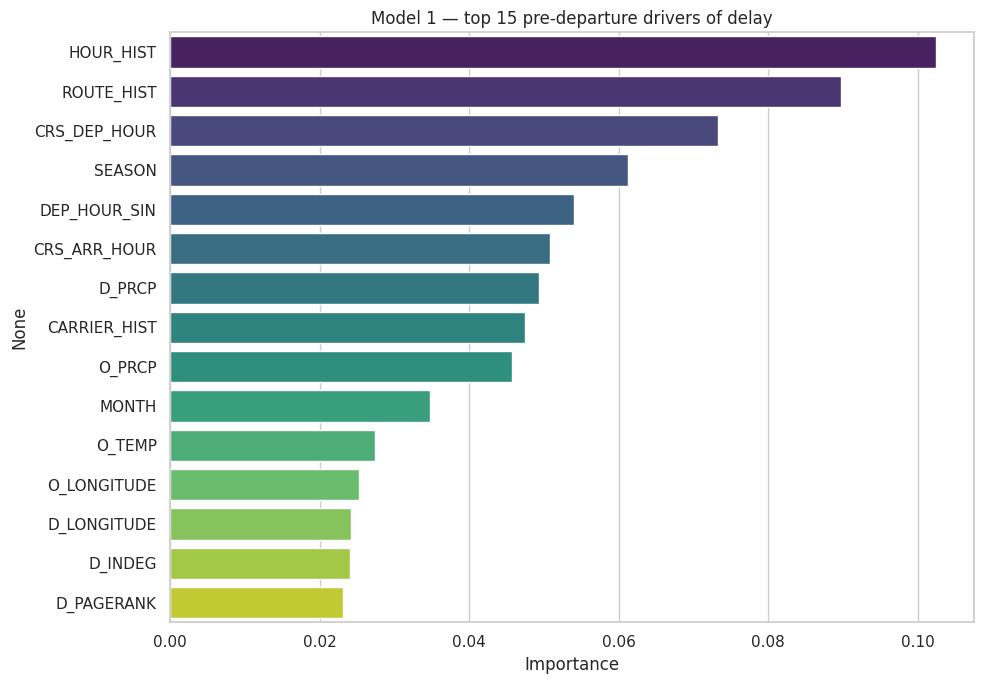

Notice the engineered features (HOUR_HIST, ROUTE_HIST, PageRank) near the top —
these are exactly what the original notebook was missing.


In [ ]:
imp = pd.Series(clf.feature_importances_, index=PRE_DEPARTURE).sort_values(ascending=False)
plt.figure(figsize=(10,7))
sns.barplot(x=imp.values[:15], y=imp.index[:15], palette="viridis")
plt.title("Model 1 — top 15 pre-departure drivers of delay"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()
print("Notice the engineered features (HOUR_HIST, ROUTE_HIST, PageRank) near the top —")
print("these are exactly what the original notebook was missing.")